# Triage Automatico

## Proyecto de inteligencia artificial
### Alejandro Roa
### Alisson Navarro
### Laura Holguin


En este cuaderno se entrenan diferentes modelos para escoger cual es el mejor clasificador para un triaje. El triaje (también escrito triage) es un método de selección y clasificación de pacientes utilizado en la enfermería y la medicina de emergencias y desastres, cuyo objetivo es evaluar las prioridades de atención según la gravedad de la condición clínica y los recursos disponibles.  

Entrenaremos un modelo de regresion logistica multiclase, una svm, una rna y un random forest, comparamos elegimos el mejor modelo para este caso en especifico.

In [188]:
#Importamos las librerias necesarias para nuestro proyecto

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Métricas
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l1, l2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

# Guardar modelos
import joblib


Para este proyecto utilizaremos una base de datos de Kaggle


Link dataset : https://www.kaggle.com/datasets/ilkeryildiz/emergency-service-triage-application


A continuación información sobre la base de datos que encontramos en el link del data set, tambien nos damos cuenta que poseemos una gran cantidad de variables que aunque se represntan numericamente realmente son variables categoricas

## Acerca del conjunto de datos

**Contexto**

Este estudio retrospectivo transversal se basó en 1267 registros seleccionados sistemáticamente de pacientes adultos admitidos en dos departamentos de urgencias entre octubre de 2016 y septiembre de 2017. Se evaluaron 24 variables, incluyendo los motivos principales de consulta, signos vitales según los registros iniciales de enfermería y los resultados clínicos.

Tres expertos en triage —una enfermera certificada en emergencias, un proveedor e instructor de KTAS y una enfermera recomendada por su excelente experiencia y competencia en el servicio de urgencias— determinaron el verdadero nivel KTAS.

**Contenido**

Variables:
* Sex: Sexo del paciente
* Age: Edad del paciente
* Arrival mode: Tipo de transporte utilizado para llegar al hospital
* Injury: Indica si el paciente presenta una lesión o no
* Chief_complain: Motivo principal de consulta del paciente
* Mental: Estado mental del paciente
* Pain: Indica si el paciente presenta dolor
* NRS_pain: Evaluación del dolor realizada por enfermería
* SBP: Presión arterial sistólica
* DBP: Presión arterial diastólica
* HR: Frecuencia cardíaca
* RR: Frecuencia respiratoria
* BT: Temperatura corporal

El documento técnico del proyecto del conjunto de datos fue consultado. En este documento se observó que algunos datos numéricos eran en realidad variables categóricas. Los valores son los siguientes:

* Reason Visit / Injury:
1 = No
2 = Sí
* Gender / Sex:
1 = Femenino
2 = Masculino
* Pain:
1 = Sí
0 = No
* Mental:
1 = Alerta
2 = Respuesta verbal
3 = Respuesta al dolor
4 = Sin respuesta
* Type of ED / Group:
1 = Servicio de urgencias local de tercer nivel
2 = Servicio de urgencias regional de cuarto nivel
* Mode of Arrival / Arrival Mode:
1 = Caminando
2 = Ambulancia pública
3 = Vehículo privado
4 = Ambulancia privada
5, 6, 7 = Otros
* Disposition:
1 = Alta médica
2 = Hospitalización en sala general
3 = Ingreso a UCI
4 = Alta médica
5 = Traslado
6 = Fallecimiento
7 = Cirugía
* KTAS:
1, 2, 3 = Emergencia
4, 5 = No emergencia

## Ahora pasaremos a cargar y limpiar el dataset

In [21]:
#Cargamos y visualizamos el dataset
df = pd.read_csv("/content/data.csv",sep=';',encoding="latin1", header = 0)
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT                      

In [4]:
df.describe()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min,mistriage
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,3.335438,1.609313,3.265983,0.558011,11016.102605,0.250197
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,0.885391,1.157983,0.885803,1.571489,80446.092065,0.628250
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,1.000000,3.000000,0.000000,133.000000,0.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,0.000000,274.000000,0.000000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,4.000000,0.000000,606.500000,0.000000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,5.000000,7.000000,5.000000,9.000000,709510.000000,2.000000


## Verificamos si hay nulos y procedemos a tratarlos para limpiar el data set

In [5]:
df.isnull().sum()

,0
Group,0
Sex,0
Age,0
Patients number per hour,0
Arrival mode,0
Injury,0
Chief_complain,0
Mental,0
Pain,0
NRS_pain,0


In [6]:
df.isnull().sum().sum()

np.int64(690)

In [23]:
# Eliminamos filas con nulos en esa columna, ya que solo son 2
df = df.dropna(subset=["Diagnosis in ED"])

In [24]:
# Verificamos
df["Diagnosis in ED"].isnull().sum()

np.int64(0)

Tenemos 688 datos nulos en el data set sobre la saturación, no podemos eliminar estas filas porque son el 50% del data set, investigando un poco mas sobre el tema hay una gran posibilidad de que el dato de la saturación no exista, porque no se tomo debido a las condiciones del paciente, lo que tambien es un idicador, asi que crearemos una bandera para indicar que no se tomo sarturación y rellenamos los nulos con la mediana

In [25]:
# 1. Crear bandera de dato faltante
df["Saturation_missing"] = df["Saturation"].isnull().astype(int)

# 2. Convertir Saturation a numérica
df["Saturation"] = pd.to_numeric(df["Saturation"], errors="coerce")

# 3. Rellenar nulos con la mediana
df["Saturation"] = df["Saturation"].fillna(df["Saturation"].median())

# 4. Verificar
df["Saturation"].isnull().sum(), df["Saturation"].dtype

(np.int64(0), dtype('float64'))

In [26]:
#Verificamos que no nos queden nulos
df.isnull().sum().sum()

np.int64(0)

## Ahora trataremos los nulos del dataset que no son explicitamente nulos

In [27]:
# Exploramos el dataset columna por columna y agrupamos para visualizar
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].astype(str).value_counts().head(20))


===== Group =====
Group
1    688
2    577
Name: count, dtype: int64

===== Sex =====
Sex
2    659
1    606
Name: count, dtype: int64

===== Age =====
Age
58    36
74    29
68    28
77    28
56    27
75    27
27    25
69    25
79    25
22    25
59    24
72    24
57    24
65    24
53    24
78    24
81    23
60    23
67    22
29    21
Name: count, dtype: int64

===== Patients number per hour =====
Patients number per hour
5     160
8     145
6     143
9     137
7     136
10    113
4      85
12     84
3      82
11     56
13     34
2      31
15     22
1      16
14     13
17      8
Name: count, dtype: int64

===== Arrival mode =====
Arrival mode
3    751
2    266
4    155
1     79
6     10
5      2
7      2
Name: count, dtype: int64

===== Injury =====
Injury
1    1022
2     243
Name: count, dtype: int64

===== Chief_complain =====
Chief_complain
abd pain            72
dyspnea             59
dizziness           59
fever               45
ant. chest pain     44
Open Wound          31
headache

Aqui hacemos un acote importante que nos servira para despues: al agrupar y visualizar notamos que en la columna de Diagnosis in ED y Chief complain hay cosas que son lo mismo pero escrito de manera diferente, lo agruparemos posteriormente.

In [28]:
# Identificamos caracteres raros o nulos no explícitos y contamos cada valor

for col in df.columns:
    mask = df[col].astype(str).str.contains(r"#|Þ|\?|!", regex=True, na=False)

    if mask.sum() > 0:
        print(f"\n===== {col} =====")
        print("Total de valores raros:", mask.sum())
        print(df.loc[mask, col].value_counts())


===== Chief_complain =====
Total de valores raros: 22
Chief_complain
??            5
????          4
??? ??        3
?? ??         2
?? ???        2
???           2
?? ??? ??     1
??? ? ???     1
Pain, ?nus    1
??? ??? ??    1
Name: count, dtype: int64

===== NRS_pain =====
Total de valores raros: 555
NRS_pain
#BOÞ!    555
Name: count, dtype: int64

===== SBP =====
Total de valores raros: 25
SBP
??    25
Name: count, dtype: int64

===== DBP =====
Total de valores raros: 29
DBP
??    29
Name: count, dtype: int64

===== HR =====
Total de valores raros: 20
HR
??    20
Name: count, dtype: int64

===== RR =====
Total de valores raros: 22
RR
??    22
Name: count, dtype: int64

===== BT =====
Total de valores raros: 18
BT
??    18
Name: count, dtype: int64


Aqui analizaremos cada caso para definir que es lo mejor para cada uno

Empezaremos con el dolor reportado por la enferemera, nos damos cuenta que este es nulo cuando el paciente no reporta dolor o este es muy bajo, probablemente porque para la enfermela el valor fue 0 o no lo midio asi que lo remplazaremos por 0

In [29]:
# Reemplazar #BOÞ! por 0
df["NRS_pain"] = df["NRS_pain"].replace("#BOÞ!", 0)

# Convertir a numérico
df["NRS_pain"] = pd.to_numeric(df["NRS_pain"])

Ahora para los datos corruptos de chief_complain que es la razon por la cual llego a urgencias el paciente, los remplazaremos por desconocido ya que no sabemos la razon o pudo haber llegado en un estado en el que no la podia comunicar

In [30]:
df["Chief_complain"] = df["Chief_complain"].replace(
    [r".*\?.*"],
    "unknown",
    regex=True
)

Aprovechamos para normalizar los datos de esta columna

In [31]:
#convierte todo el texto a minúsculas y eliminamos espacios al inicio y al final
df["Chief_complain"] = (
    df["Chief_complain"]
    .str.lower()
    .str.strip()
)

# Unificar nombres que significan lo mismo
df["Chief_complain"] = df["Chief_complain"].replace({
    "abd. pain": "abdominal pain",
    "abd pain": "abdominal pain",
    "abdomen pain": "abdominal pain",
    "pain, chest": "chest pain",
    "left chest pain": "chest pain",
    "ant. chest pain": "chest pain"
})

In [32]:
#revisamos como nos quedaron los datos normalizados
df["Chief_complain"].value_counts()

,count
Chief_complain,
abdominal pain,94
chest pain,72
dyspnea,59
dizziness,59
fever,45
...,...
abdomen distension,1
behavior change,1
g/w-general weakness,1


Ahora para SBP, DBP, RR y BT ya que son signos vitales que no conocemos y no son muchos, los rellenaremos con la mediana

In [33]:
cols = ["SBP", "DBP", "HR", "RR", "BT"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [34]:
#Visualizamos como nos quedo nuestro data frame
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage,Saturation_missing
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,100.0,2,Corneal abrasion,1,4,2,86,"5,00",1,0
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,98.0,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1,1
2,2,1,68,8,2,2,"arm pain, lt",1,1,2,...,98.0,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1,0
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,98.0,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,98.0,4,Ascites,1,5,8,109,"6,60",1,1


##Ahora separamos nuestros datos de entrenamiento y de test
Para nuestro Y o etiqueta tomaremos el KTAS expert, eliminaremos el otro ktas y columnas que solo sabemos los datos hasta despues de que ya se hizo el triage para no tener un problema de data leak, porque ya que el objetivo es automatizar el triage en la inferencia no tendremos un ktas ya que es el objetivo

In [36]:
#Eliminamos el otro ktas, y el mistriage ya que es una metrica sobre el ktas rn
df = df.drop(columns=["KTAS_RN","mistriage","Disposition","Diagnosis in ED","Error_group","Length of stay_min","KTAS duration_min"])

In [37]:
#Separamos X y visualizamos
X = df.drop(columns=["KTAS_expert"])
X.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,Saturation_missing
0,2,2,71,3,3,2,right ocular pain,1,1,2,160.0,100.0,84.0,18.0,36.6,100.0,0
1,1,1,56,12,3,2,right forearm burn,1,1,2,137.0,75.0,60.0,20.0,36.5,98.0,1
2,2,1,68,8,2,2,"arm pain, lt",1,1,2,130.0,80.0,102.0,20.0,36.6,98.0,0
3,1,2,71,8,1,1,ascites tapping,1,1,3,139.0,94.0,88.0,20.0,36.5,98.0,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,91.0,67.0,93.0,18.0,36.5,98.0,1


In [38]:
#Separamos Y y visualizamos
Y = df["KTAS_expert"]
Y.head()

,KTAS_expert
0,4
1,5
2,5
3,5
4,5


In [39]:
# Ahora si separamos el conjunto de entrenamiento y prueba
X_train, X_test, y_train , y_test = train_test_split(X, Y, random_state=42, test_size= 0.2, stratify=Y)

## Ahora podemos proceder a codificar las variables categoricas

Segun nuestra base de datos tenemos que las variables categoricas son:
* Chief_complain: Motivo principal de consulta del paciente
* Diagnosisi in ED
* Reason Visit / Injury:
1 = No
2 = Sí
* Gender / Sex:
1 = Femenino
2 = Masculino
* Pain:
1 = Sí
0 = No
* Mental:
1 = Alerta
2 = Respuesta verbal
3 = Respuesta al dolor
4 = Sin respuesta
* Type of ED / Group:
1 = Servicio de urgencias local de tercer nivel
2 = Servicio de urgencias regional de cuarto nivel
* Mode of Arrival / Arrival Mode:
1 = Caminando
2 = Ambulancia pública
3 = Vehículo privado
4 = Ambulancia privada
5, 6, 7 = Otros
* Disposition:
1 = Alta médica
2 = Hospitalización en sala general
3 = Ingreso a UCI
4 = Alta médica
5 = Traslado
6 = Fallecimiento
7 = Cirugía
* KTAS:
1, 2, 3 = Emergencia
4, 5 = No emergencia


Usaremos una codificación one hot encoder para nuestras variables categoricas

In [40]:
#Separamos nuestro df de categoricas del X train
df_categoricas_train = X_train[["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Pain","Saturation_missing"]]
df_categoricas_train.head()

,Group,Sex,Arrival mode,Injury,Chief_complain,Mental,Pain,Saturation_missing
224,1,1,3,1,for a/tapping,1,1,1
740,1,2,3,1,lt flank pain,1,1,1
1194,2,1,2,1,hematemesis,1,0,0
951,1,1,3,1,dizziness,1,0,1
964,2,2,3,1,chest palpitation,1,0,0


In [41]:
#Ahora lo hacemos con X test
df_categoricas_test = X_test[["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Pain","Saturation_missing"]]
df_categoricas_test.head()

,Group,Sex,Arrival mode,Injury,Chief_complain,Mental,Pain,Saturation_missing
230,1,1,3,1,acute epigastric pain,1,1,1
874,1,2,3,2,finger laceration,1,0,1
465,1,1,3,1,abdominal pain,1,1,1
790,1,2,2,1,post seizure,2,0,1
873,1,1,3,1,facial palsy,1,0,1


###Ahora instanciamos nuestro codificador y codificamos nuestro df categorico

In [42]:
#Instanciamos el codificador
encoder = OneHotEncoder(handle_unknown="ignore")
#Codificamos
df_categoricas_train_1hot = encoder.fit_transform(df_categoricas_train)

(Oportunidad de mejora, TF-IDF en vez de one hot)

In [43]:
#Ahora con los datos de test
df_categoricas_test_1hot = encoder.transform(df_categoricas_test)

In [44]:
# creamos un nuevo dataFrame con las nuevas columnas
df_categoricas_train = pd.DataFrame(df_categoricas_train_1hot.toarray() ,
                         columns=encoder.get_feature_names_out())

In [45]:
df_categoricas_train.head()

,Group_1,Group_2,Sex_1,Sex_2,Arrival mode_1,Arrival mode_2,Arrival mode_3,Arrival mode_4,Arrival mode_5,Arrival mode_6,...,Chief_complain_wrist injury,Chief_complain_wrist laceration,Mental_1,Mental_2,Mental_3,Mental_4,Pain_0,Pain_1,Saturation_missing_0,Saturation_missing_1
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [46]:
# ahora con los datos de test
df_categoricas_test = pd.DataFrame(df_categoricas_test_1hot.toarray() ,
                         columns=encoder.get_feature_names_out())

In [47]:
df_categoricas_test.head()

,Group_1,Group_2,Sex_1,Sex_2,Arrival mode_1,Arrival mode_2,Arrival mode_3,Arrival mode_4,Arrival mode_5,Arrival mode_6,...,Chief_complain_wrist injury,Chief_complain_wrist laceration,Mental_1,Mental_2,Mental_3,Mental_4,Pain_0,Pain_1,Saturation_missing_0,Saturation_missing_1
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


##Ahora vamos estandarizar los datos

In [49]:
#primero borramos las columnas de nuestras variables categoricas
X_train = X_train.drop(columns=["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Pain","Saturation_missing"])

In [50]:
#Ahora de nuestro X test
X_test = X_test.drop(columns=["Group","Sex","Arrival mode","Injury","Chief_complain","Mental","Pain","Saturation_missing"])

In [51]:
# Convertir todo X_train y X_test a numérico
# Reemplaza comas decimales por puntos y convierte errores a NaN

X_train = X_train.astype(str).replace(",", ".", regex=True)
X_test = X_test.astype(str).replace(",", ".", regex=True)
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

In [52]:
#instanciamos nuestro scalador
st_x = StandardScaler()
X_train_std = st_x.fit_transform(X_train)
X_test_std = st_x.transform(X_test)

In [53]:
#Concatenamos nuestras categoricas
X_train_std = pd.concat([pd.DataFrame(X_train_std, columns=X_train.columns), df_categoricas_train], axis=1)
X_train_std

,Age,Patients number per hour,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,Group_1,...,Chief_complain_wrist injury,Chief_complain_wrist laceration,Mental_1,Mental_2,Mental_3,Mental_4,Pain_0,Pain_1,Saturation_missing_0,Saturation_missing_1
0,0.924739,-0.821715,0.286350,-0.088289,-1.739274,-0.888048,-1.727604,1.558242,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.559415,0.136690,2.003599,2.463471,1.686440,0.251146,-1.727604,-1.862866,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.538872,0.775626,-1.001587,0.614370,1.350586,0.970638,0.262533,0.037749,-0.476992,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.303527,-0.821715,-1.001587,-1.160768,-2.343812,-1.487624,-0.732535,-0.532435,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.201171,-0.182779,-1.001587,-1.234732,-1.336249,1.570213,0.262533,-0.722497,-0.476992,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,0.105895,-1.460652,0.715662,1.095136,0.947561,-0.048641,-1.727604,0.797996,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1008,0.208251,0.136690,-1.001587,-0.125271,0.007168,-2.866648,0.262533,-0.722497,-0.166564,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1009,0.003540,-0.182779,3.291536,0.688334,1.081902,-2.027242,-1.727604,0.227811,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1010,1.027095,0.775626,0.286350,-1.234732,-1.336249,-0.708175,-0.732535,0.037749,-0.166564,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [54]:
#Ahora con el conjunto de test
X_test_std = pd.concat([pd.DataFrame(X_test_std, columns=X_test.columns), df_categoricas_test], axis=1)
X_test_std

,Age,Patients number per hour,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,Group_1,...,Chief_complain_wrist injury,Chief_complain_wrist laceration,Mental_1,Mental_2,Mental_3,Mental_4,Pain_0,Pain_1,Saturation_missing_0,Saturation_missing_1
0,-0.968837,0.456158,0.286350,0.281531,0.208681,-1.547581,-1.727604,-0.722497,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-1.275904,0.136690,-1.001587,-0.162253,-0.261515,0.191189,-0.732535,0.417873,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.531792,1.414563,0.715662,-0.569056,-1.067565,-0.768133,0.262533,0.227811,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.259429,-0.182779,-1.001587,1.797795,-0.395857,1.870001,-0.732535,-1.102620,0.143865,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-1.327081,0.775626,-1.001587,0.022657,-0.261515,-0.948005,0.262533,0.797996,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,0.975917,-1.141184,2.003599,0.059639,1.417757,1.150510,-0.732535,-0.722497,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
249,-1.020015,-1.141184,-1.001587,0.836262,1.081902,2.349662,-0.732535,-0.152312,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
250,0.566495,-0.182779,-1.001587,0.355495,0.477365,2.829323,0.262533,-1.102620,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
251,-1.224726,0.775626,0.286350,2.426489,2.156636,1.630171,0.262533,0.607934,0.143865,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


##Guardamos nuestro scaler y encoder

In [103]:
joblib.dump(st_x, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

#Ahora entrenamos diferentes modelos

##Regresion logistica

In [55]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_std, y_train)
y_pred = logreg.predict(X_test_std)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


###Ahora evaluamos nuestro modelo de regresion con distintas metricas

In [57]:
# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision macro:", precision_macro)
print("Recall macro:", recall_macro)
print("F1 macro:", f1_macro)
print("Precision weighted:", precision_weighted)
print("Recall weighted:", recall_weighted)
print("F1 weighted:", f1_weighted)

print("\nReporte completo:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6561264822134387
Precision macro: 0.5940049622064508
Recall macro: 0.4859308911617294
F1 macro: 0.5118575491391025
Precision weighted: 0.6218010952979457
Recall weighted: 0.6561264822134387
F1 weighted: 0.6331723876449307

Reporte completo:
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.67      0.55      0.60        44
           3       0.61      0.69      0.65        97
           4       0.69      0.79      0.74        92
           5       0.00      0.00      0.00        15

    accuracy                           0.66       253
   macro avg       0.59      0.49      0.51       253
weighted avg       0.62      0.66      0.63       253



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

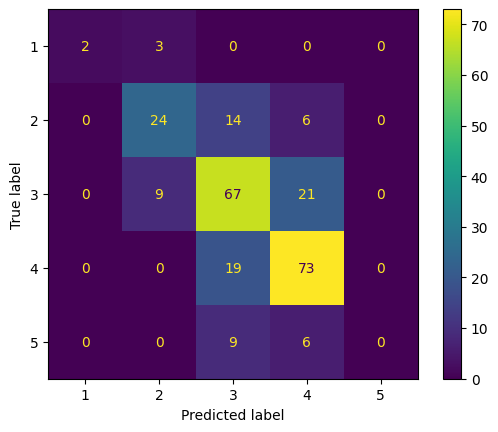

In [76]:
#Matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

###Ahora guardamos nuestro modelo

In [62]:
joblib.dump(logreg, "modelo_logreg.pkl")

['modelo_logreg.pkl']

## SVM

###Ahora buscaremos el mejor SVM

In [63]:
# Definir el modelo SVM
svm_clf = SVC(class_weight="balanced")

In [64]:
# Definir la cuadrícula de hiperparámetros
param_grid_svm = [
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 50, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1, 1]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", 0.001, 0.01, 0.1],
        "degree": [2, 3, 4],
        "coef0": [0, 0.5, 1]
    },
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10, 100]
    }
]

In [66]:
# Configurar el GridSearch con validación cruzada de 5 conjuntos
grid_search_svm = GridSearchCV(estimator=svm_clf,param_grid=param_grid_svm,scoring="f1_macro",cv=5)

In [68]:
# Entrenar con el conjunto de parámetros
grid_search_svm.fit(X_train_std, np.ravel(y_train))

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'),
             param_grid=[{'C': [0.1, 1, 10, 50, 100],
                          'gamma': ['scale', 0.001, 0.01, 0.1, 1],
                          'kernel': ['rbf']},
                         {'C': [0.1, 1, 10, 50], 'coef0': [0, 0.5, 1],
                          'degree': [2, 3, 4],
                          'gamma': ['scale', 0.001, 0.01, 0.1],
                          'kernel': ['poly']},
                         {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear']}],
             scoring='f1_macro')

In [69]:
# Imprimir los mejores hiperparámetros
print("Mejores hiperparámetros para SVM:", grid_search_svm.best_params_)

Mejores hiperparámetros para SVM: {'C': 50, 'gamma': 0.01, 'kernel': 'rbf'}


In [70]:
# Predicciones
y_pred_svm_best = grid_search_svm.best_estimator_.predict(X_test_std)
y_pred_svm_best

array([4, 4, 3, 3, 3, 2, 4, 3, 4, 2, 2, 4, 3, 4, 3, 4, 3, 4, 4, 3, 3, 4,
       4, 4, 4, 3, 3, 4, 3, 4, 2, 4, 3, 4, 2, 1, 3, 4, 4, 2, 4, 3, 3, 3,
       4, 3, 3, 3, 3, 2, 3, 4, 4, 3, 4, 4, 3, 3, 4, 4, 3, 4, 2, 3, 3, 3,
       3, 4, 4, 4, 3, 4, 2, 3, 1, 5, 3, 3, 4, 2, 4, 3, 4, 2, 2, 4, 3, 2,
       4, 4, 4, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 3, 3, 2, 3, 2, 4, 2, 4,
       3, 2, 5, 3, 4, 2, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3,
       2, 3, 4, 3, 2, 3, 4, 3, 2, 2, 2, 4, 4, 2, 4, 3, 2, 2, 2, 4, 4, 4,
       4, 3, 1, 3, 4, 2, 3, 4, 2, 3, 4, 3, 2, 3, 4, 4, 2, 4, 3, 2, 3, 3,
       2, 4, 4, 2, 2, 2, 4, 2, 4, 3, 5, 3, 2, 5, 2, 4, 3, 4, 2, 2, 4, 4,
       3, 2, 2, 3, 2, 3, 3, 3, 2, 4, 3, 3, 4, 4, 4, 3, 3, 4, 4, 4, 4, 4,
       4, 3, 4, 4, 3, 4, 4, 4, 2, 3, 3, 3, 4, 2, 3, 2, 2, 3, 2, 3, 2, 3,
       4, 3, 4, 4, 3, 4, 4, 3, 3, 4, 2])

### Ahora evaluamos nuestro modelo

In [71]:
#Principales metricas
accuracy_svm = accuracy_score(y_test, y_pred_svm_best)
precision_macro_svm = precision_score(y_test, y_pred_svm_best, average="macro")
recall_macro_svm = recall_score(y_test, y_pred_svm_best, average="macro")
f1_macro_svm = f1_score(y_test, y_pred_svm_best, average="macro")

precision_weighted_svm = precision_score(y_test, y_pred_svm_best, average="weighted")
recall_weighted_svm = recall_score(y_test, y_pred_svm_best, average="weighted")
f1_weighted_svm = f1_score(y_test, y_pred_svm_best, average="weighted")

print(f"Accuracy SVM: {accuracy_svm * 100:.2f}%")
print("Precision macro:", precision_macro_svm)
print("Recall macro:", recall_macro_svm)
print("F1 macro:", f1_macro_svm)
print("Precision weighted:", precision_weighted_svm)
print("Recall weighted:", recall_weighted_svm)
print("F1 weighted:", f1_weighted_svm)

print("\nReporte completo:")
print(classification_report(y_test, y_pred_svm_best))

Accuracy SVM: 66.01%
Precision macro: 0.6225737639553429
Recall macro: 0.5274726647922524
F1 macro: 0.545521319484649
Precision weighted: 0.6565637785174397
Recall weighted: 0.6600790513833992
F1 weighted: 0.6499325031272972

Reporte completo:
              precision    recall  f1-score   support

           1       0.67      0.40      0.50         5
           2       0.56      0.70      0.63        44
           3       0.66      0.65      0.65        97
           4       0.73      0.75      0.74        92
           5       0.50      0.13      0.21        15

    accuracy                           0.66       253
   macro avg       0.62      0.53      0.55       253
weighted avg       0.66      0.66      0.65       253



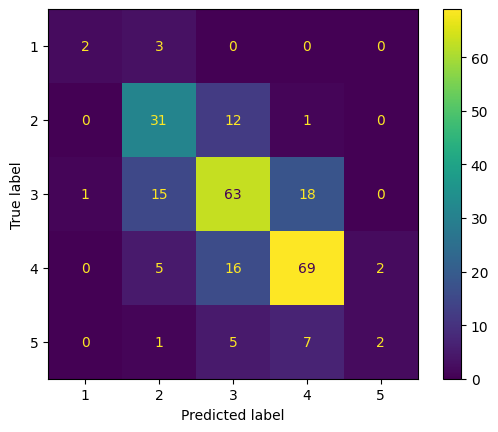

In [72]:
#Matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_svm_best)

###Ahora guardamos nuestro modelo

In [74]:
svm_best = grid_search_svm.best_estimator_
joblib.dump(svm_best, "modelo_svm.pkl")

['modelo_svm.pkl']

##Red Neuronal

In [91]:
# Aplanar y convertir KTAS de 1-5 a 0-4
y_train_rna = np.ravel(y_train).astype(int) - 1
y_test_rna = np.ravel(y_test).astype(int) - 1
print("Forma y_train:", y_train_rna.shape)
print("Clases y_train:", np.unique(y_train_rna))

Forma y_train: (1012,)
Clases y_train: [0 1 2 3 4]


In [92]:
#Calculamos los pesos de nuestras clases porque estan muy desbalanceadas
classes = np.unique(y_train_rna)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_rna
)
class_weights = dict(zip(classes, weights))
print("Pesos:", class_weights)

Pesos: {np.int64(0): np.float64(9.638095238095238), np.int64(1): np.float64(1.1565714285714286), np.int64(2): np.float64(0.518974358974359), np.int64(3): np.float64(0.5530054644808743), np.int64(4): np.float64(3.3733333333333335)}


In [173]:
#Creamos y definimos la arquitectura de nuestra red neuronal
model = Sequential([
    Input(shape=(X_train_std.shape[1],)),

    Dense(64, activation="relu",kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    BatchNormalization(),

    Dense(32, activation="relu",kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(5, activation="softmax")
])

In [174]:
#Compilamos la funcion que deseamos optimizar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [175]:
#Definimos el early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True
)


In [176]:
#Entrenamos nuestra red neuronal
history = model.fit(
    X_train_std,
    y_train_rna,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1434 - loss: 2.1422 - val_accuracy: 0.2906 - val_loss: 1.7263
Epoch 2/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1916 - loss: 1.8752 - val_accuracy: 0.3596 - val_loss: 1.6953
Epoch 3/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2410 - loss: 1.7626 - val_accuracy: 0.3941 - val_loss: 1.6674
Epoch 4/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2707 - loss: 1.6531 - val_accuracy: 0.4089 - val_loss: 1.6435
Epoch 5/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3028 - loss: 1.5948 - val_accuracy: 0.4089 - val_loss: 1.6213
Epoch 6/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3140 - loss: 1.5316 - val_accuracy: 0.4187 - val_loss: 1.5977
Epoch 7/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3387 - loss: 1.4792 - val_accuracy: 0.4236 - val_loss: 1.5750
Epoch 8/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3201 - loss: 1.4285 - val_accuracy: 0.4335 - 

In [177]:
y_pred_probs = model.predict(X_test_std)
y_pred_rna = np.argmax(y_pred_probs, axis=1)

# Volver de 0-4 a 1-5
y_pred_rna_original = y_pred_rna + 1

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


### Ahora evaluamos nuestra RNA

In [178]:
#Principales metricas
accuracy_rna = accuracy_score(y_test, y_pred_rna_original)

precision_macro_rna = precision_score(y_test, y_pred_rna_original, average="macro")
recall_macro_rna = recall_score(y_test, y_pred_rna_original, average="macro")
f1_macro_rna = f1_score(y_test, y_pred_rna_original, average="macro")

precision_weighted_rna = precision_score(y_test, y_pred_rna_original, average="weighted")
recall_weighted_rna = recall_score(y_test, y_pred_rna_original, average="weighted")
f1_weighted_rna = f1_score(y_test, y_pred_rna_original, average="weighted")

print(f"Accuracy RNA: {accuracy_rna * 100:.2f}%")
print("Precision macro:", precision_macro_rna)
print("Recall macro:", recall_macro_rna)
print("F1 macro:", f1_macro_rna)
print("Precision weighted:", precision_weighted_rna)
print("Recall weighted:", recall_weighted_rna)
print("F1 weighted:", f1_weighted_rna)

print("\nReporte completo:")
print(classification_report(y_test, y_pred_rna_original))

Accuracy RNA: 63.24%
Precision macro: 0.5337994060500455
Recall macro: 0.573737283185961
F1 macro: 0.5486297031375365
Precision weighted: 0.6485114370414049
Recall weighted: 0.6324110671936759
F1 weighted: 0.6378903018096426

Reporte completo:
              precision    recall  f1-score   support

           1       0.43      0.60      0.50         5
           2       0.59      0.61      0.60        44
           3       0.65      0.68      0.66        97
           4       0.76      0.64      0.69        92
           5       0.25      0.33      0.29        15

    accuracy                           0.63       253
   macro avg       0.53      0.57      0.55       253
weighted avg       0.65      0.63      0.64       253



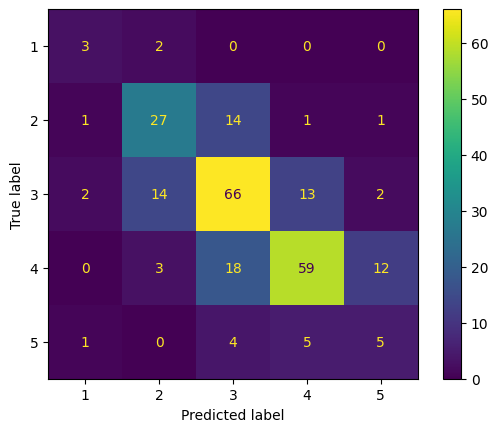

In [179]:
#Matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rna_original)

### Ahora guardamos nuestra RNA

In [181]:
model.save("modelo_rna.keras")

##Random Forest


In [167]:
# Crear modelo
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [168]:
# Entrenar
rf.fit(X_train_std, np.ravel(y_train))

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [169]:
# Predecir
y_pred_rf = rf.predict(X_test_std)

### Ahora evaluamos nuestro modelo

In [170]:
#Metricas principales
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_macro_rf = precision_score(y_test, y_pred_rf, average="macro")
recall_macro_rf = recall_score(y_test, y_pred_rf, average="macro")
f1_macro_rf = f1_score(y_test, y_pred_rf, average="macro")

precision_weighted_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_weighted_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_weighted_rf = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Accuracy Random Forest: {accuracy_rf * 100:.2f}%")
print("Precision macro:", precision_macro_rf)
print("Recall macro:", recall_macro_rf)
print("F1 macro:", f1_macro_rf)
print("Precision weighted:", precision_weighted_rf)
print("Recall weighted:", recall_weighted_rf)
print("F1 weighted:", f1_weighted_rf)

print("\nReporte completo:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 67.98%
Precision macro: 0.6216925980904209
Recall macro: 0.4881435149341917
F1 macro: 0.5194729515163108
Precision weighted: 0.658043695928514
Recall weighted: 0.6798418972332015
F1 weighted: 0.6549272477601953

Reporte completo:
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.74      0.45      0.56        44
           3       0.61      0.81      0.70        97
           4       0.76      0.77      0.76        92
           5       0.00      0.00      0.00        15

    accuracy                           0.68       253
   macro avg       0.62      0.49      0.52       253
weighted avg       0.66      0.68      0.65       253



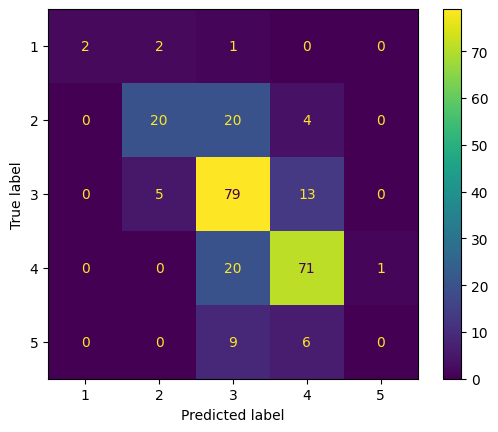

In [171]:
#Matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

###Ahora guardamos nuestro modelo

In [172]:
joblib.dump(rf, "modelo_random_forest.pkl")

['modelo_random_forest.pkl']

##XGBoost

In [189]:
#Entrenamos
!pip install xgboost -q
y_train_xgb = np.ravel(y_train).astype(int) - 1
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42
)
xgb.fit(X_train_std, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=5, ...)

In [190]:
#Predecimos
y_pred_xgb = xgb.predict(X_test_std) + 1

###Ahora evaluamos nuestro modelo

In [191]:
#Metricas principales
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_macro_xgb = precision_score(y_test, y_pred_xgb, average="macro")
recall_macro_xgb = recall_score(y_test, y_pred_xgb, average="macro")
f1_macro_xgb = f1_score(y_test, y_pred_xgb, average="macro")

precision_weighted_xgb = precision_score(y_test, y_pred_xgb, average="weighted")
recall_weighted_xgb = recall_score(y_test, y_pred_xgb, average="weighted")
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print(f"Accuracy XGBoost: {accuracy_xgb * 100:.2f}%")
print("Precision macro:", precision_macro_xgb)
print("Recall macro:", recall_macro_xgb)
print("F1 macro:", f1_macro_xgb)
print("Precision weighted:", precision_weighted_xgb)
print("Recall weighted:", recall_weighted_xgb)
print("F1 weighted:", f1_weighted_xgb)

print("\nReporte completo:")
print(classification_report(y_test, y_pred_xgb))

Accuracy XGBoost: 66.01%
Precision macro: 0.6778214293290341
Recall macro: 0.5050082175407142
F1 macro: 0.5491567397343842
Precision weighted: 0.6562539695688816
Recall weighted: 0.6600790513833992
F1 weighted: 0.6474950210427558

Reporte completo:
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.65      0.50      0.56        44
           3       0.62      0.75      0.68        97
           4       0.72      0.74      0.73        92
           5       0.40      0.13      0.20        15

    accuracy                           0.66       253
   macro avg       0.68      0.51      0.55       253
weighted avg       0.66      0.66      0.65       253



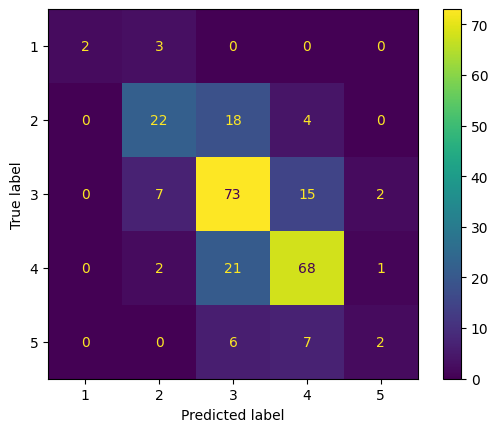

In [192]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

###Ahora guiardamos nuestro modelo

In [193]:
joblib.dump(xgb, "modelo_xgboost.pkl")

['modelo_xgboost.pkl']

##Gradient Boosting

In [194]:
#Entrenamos
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_std, np.ravel(y_train))

GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42)

In [195]:
#predecimos
y_pred_gb = gb.predict(X_test_std)

###Ahora evaluamos nuestro modelo

In [196]:
#Metricas principales
accuracy_gb = accuracy_score(y_test, y_pred_gb)

precision_macro_gb = precision_score(y_test, y_pred_gb, average="macro")
recall_macro_gb = recall_score(y_test, y_pred_gb, average="macro")
f1_macro_gb = f1_score(y_test, y_pred_gb, average="macro")

precision_weighted_gb = precision_score(y_test, y_pred_gb, average="weighted")
recall_weighted_gb = recall_score(y_test, y_pred_gb, average="weighted")
f1_weighted_gb = f1_score(y_test, y_pred_gb, average="weighted")

print(f"Accuracy Gradient Boosting: {accuracy_gb * 100:.2f}%")
print("Precision macro:", precision_macro_gb)
print("Recall macro:", recall_macro_gb)
print("F1 macro:", f1_macro_gb)
print("Precision weighted:", precision_weighted_gb)
print("Recall weighted:", recall_weighted_gb)
print("F1 weighted:", f1_weighted_gb)

print("\nReporte completo:")
print(classification_report(y_test, y_pred_gb))

Accuracy Gradient Boosting: 67.59%
Precision macro: 0.6753376344086022
Recall macro: 0.4972410795539438
F1 macro: 0.5365079365079365
Precision weighted: 0.6684136172383017
Recall weighted: 0.6758893280632411
F1 weighted: 0.6564876564876565

Reporte completo:
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.67      0.45      0.54        44
           3       0.62      0.80      0.70        97
           4       0.75      0.76      0.76        92
           5       0.33      0.07      0.11        15

    accuracy                           0.68       253
   macro avg       0.68      0.50      0.54       253
weighted avg       0.67      0.68      0.66       253



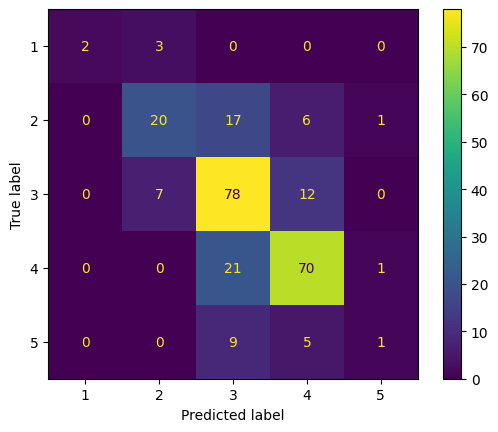

In [197]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)

###Ahora guardamos nuestro modelo

In [198]:
joblib.dump(gb, "modelo_gradient_boosting.pkl")

['modelo_gradient_boosting.pkl']

#Comparación de modelos

In [199]:
resultados_modelos = [
    {
        "Modelo": "Regresión Logística",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "Precision Weighted": precision_weighted,
        "Recall Weighted": recall_weighted,
        "F1 Weighted": f1_weighted
    },
    {
        "Modelo": "SVM",
        "Accuracy": accuracy_svm,
        "Precision Macro": precision_macro_svm,
        "Recall Macro": recall_macro_svm,
        "F1 Macro": f1_macro_svm,
        "Precision Weighted": precision_weighted_svm,
        "Recall Weighted": recall_weighted_svm,
        "F1 Weighted": f1_weighted_svm
    },
    {
        "Modelo": "RNA",
        "Accuracy": accuracy_rna,
        "Precision Macro": precision_macro_rna,
        "Recall Macro": recall_macro_rna,
        "F1 Macro": f1_macro_rna,
        "Precision Weighted": precision_weighted_rna,
        "Recall Weighted": recall_weighted_rna,
        "F1 Weighted": f1_weighted_rna
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_rf,
        "Precision Macro": precision_macro_rf,
        "Recall Macro": recall_macro_rf,
        "F1 Macro": f1_macro_rf,
        "Precision Weighted": precision_weighted_rf,
        "Recall Weighted": recall_weighted_rf,
        "F1 Weighted": f1_weighted_rf
    },
    {
        "Modelo": "XGBoost",
        "Accuracy": accuracy_xgb,
        "Precision Macro": precision_macro_xgb,
        "Recall Macro": recall_macro_xgb,
        "F1 Macro": f1_macro_xgb,
        "Precision Weighted": precision_weighted_xgb,
        "Recall Weighted": recall_weighted_xgb,
        "F1 Weighted": f1_weighted_xgb
    },
    {
        "Modelo": "Gradient Boosting",
        "Accuracy": accuracy_gb,
        "Precision Macro": precision_macro_gb,
        "Recall Macro": recall_macro_gb,
        "F1 Macro": f1_macro_gb,
        "Precision Weighted": precision_weighted_gb,
        "Recall Weighted": recall_weighted_gb,
        "F1 Weighted": f1_weighted_gb
    }
]

comparacion_modelos = pd.DataFrame(resultados_modelos)

comparacion_modelos.sort_values(
    by="F1 Macro",
    ascending=False
)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
4,XGBoost,0.660079,0.677821,0.505008,0.549157,0.656254,0.660079,0.647495
2,RNA,0.632411,0.533799,0.573737,0.548630,0.648511,0.632411,0.637890
1,SVM,0.660079,0.622574,0.527473,0.545521,0.656564,0.660079,0.649933
5,Gradient Boosting,0.675889,0.675338,0.497241,0.536508,0.668414,0.675889,0.656488
3,Random Forest,0.679842,0.621693,0.488144,0.519473,0.658044,0.679842,0.654927
0,Regresión Logística,0.656126,0.594005,0.485931,0.511858,0.621801,0.656126,0.633172


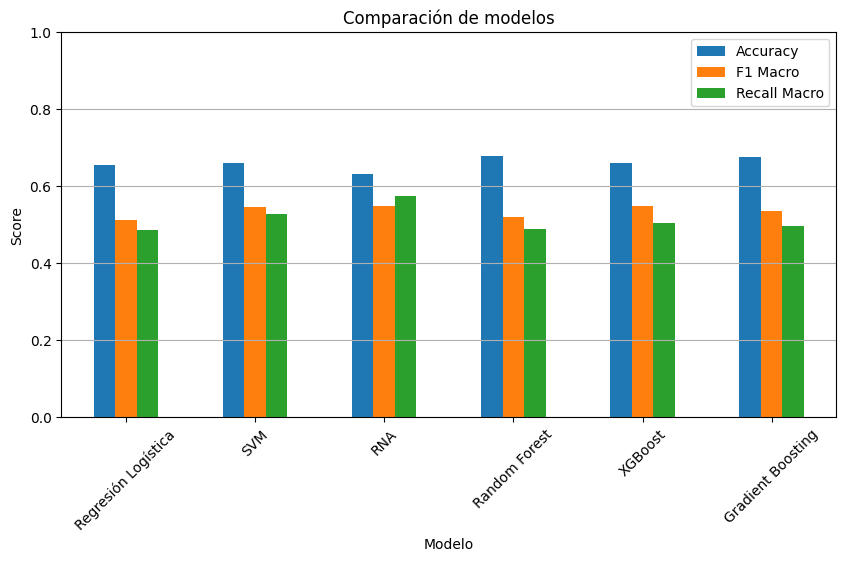

In [200]:
comparacion_modelos.set_index("Modelo")[["Accuracy", "F1 Macro", "Recall Macro"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de modelos")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

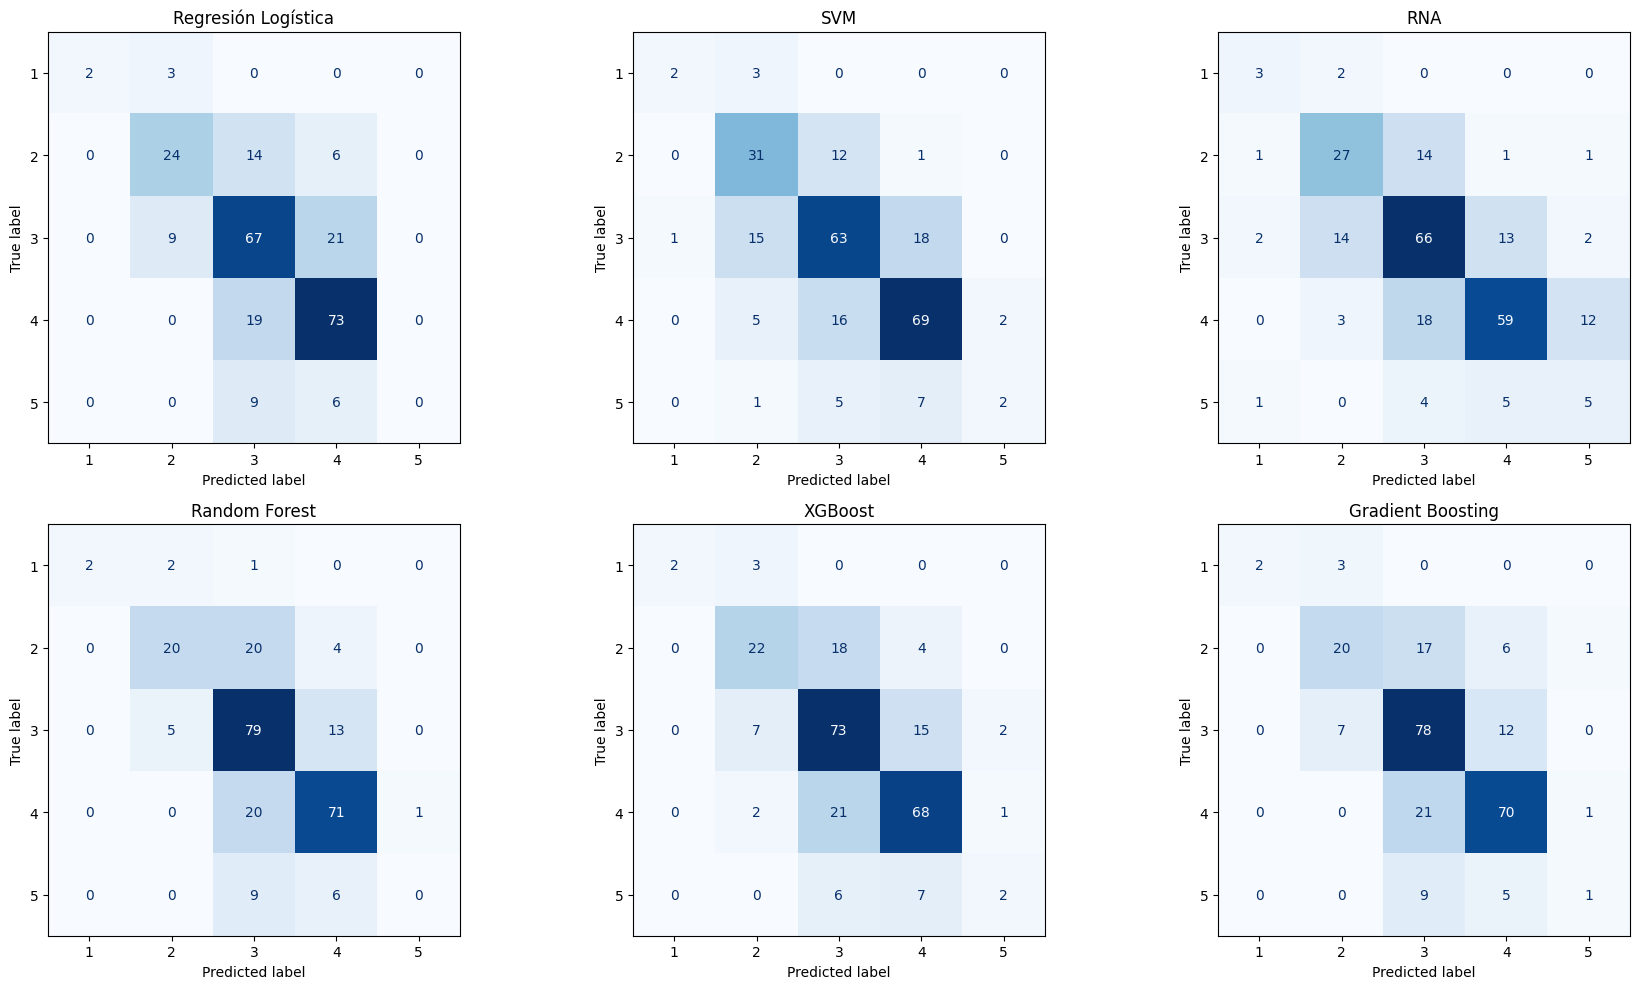

In [201]:
#Matrices de confusion
predicciones = {
    "Regresión Logística": y_pred,
    "SVM": y_pred_svm_best,
    "RNA": y_pred_rna_original,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Gradient Boosting": y_pred_gb
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (nombre, y_pred_modelo) in zip(axes.ravel(), predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_modelo,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

In [202]:
#Comparacion de clases
comparacion_precision_clases = []

for nombre, y_pred_modelo in predicciones.items():
    precision_por_clase = precision_score(
        y_test,
        y_pred_modelo,
        labels=[1, 2, 3, 4, 5],
        average=None,
        zero_division=0
    )

    comparacion_precision_clases.append({
        "Modelo": nombre,
        "Precisión Clase 1": precision_por_clase[0],
        "Precisión Clase 2": precision_por_clase[1]
    })

df_precision_clases = pd.DataFrame(comparacion_precision_clases)
df_precision_clases

,Modelo,Precisión Clase 1,Precisión Clase 2
0,Regresión Logística,1.000000,0.666667
1,SVM,0.666667,0.563636
2,RNA,0.428571,0.586957
3,Random Forest,1.000000,0.740741
4,XGBoost,1.000000,0.647059
5,Gradient Boosting,1.000000,0.666667


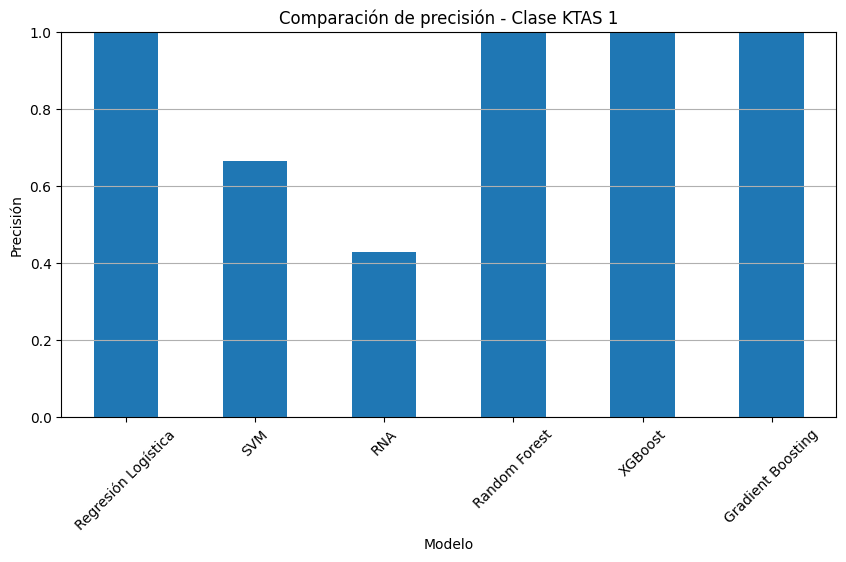

In [203]:
#Precision clase 1
df_precision_clases.plot(
    x="Modelo",
    y="Precisión Clase 1",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Comparación de precisión - Clase KTAS 1")
plt.ylabel("Precisión")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

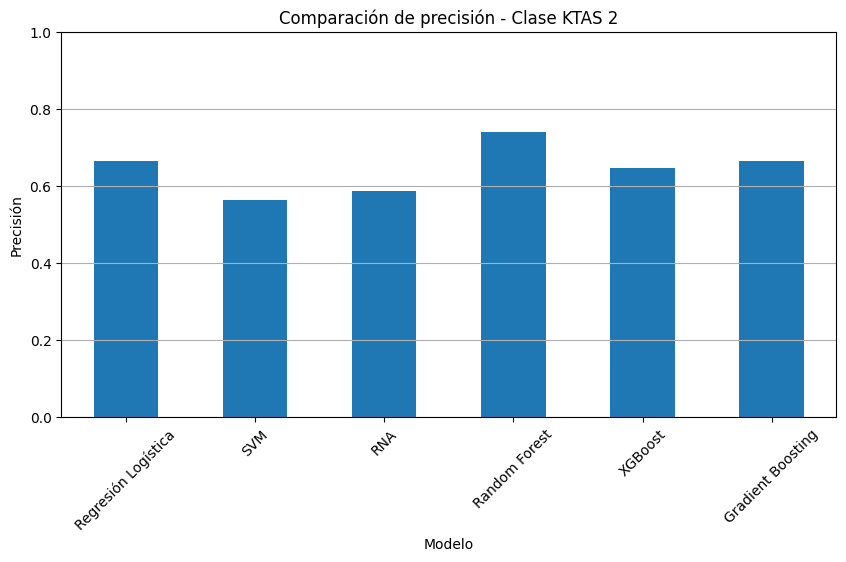

In [204]:
#Precision clase 2
df_precision_clases.plot(
    x="Modelo",
    y="Precisión Clase 2",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Comparación de precisión - Clase KTAS 2")
plt.ylabel("Precisión")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#Conclusión


Después de entrenar y evaluar múltiples modelos de aprendizaje automático, incluyendo Regresión Logística, SVM, Red Neuronal Artificial, Random Forest, XGBoost y Gradient Boosting, concluimos que para nuestro ejercicio el modelo seleccionado será Random Forest. Esta decisión no se basa únicamente en que obtuvo el mayor accuracy general, sino principalmente en su desempeño sobre las clases KTAS 1 y KTAS 2, que representan los pacientes con mayor nivel de urgencia y prioridad clínica. En el contexto de un sistema de triage, acertar en estos niveles es especialmente importante, ya que una clasificación incorrecta podría retrasar la atención de pacientes críticos.

Además, el modelo Random Forest presentó una mejor precisión y capacidad de identificación en estas clases prioritarias en comparación con los demás modelos evaluados, lo que lo convierte en la alternativa más adecuada para este caso de estudio.

Sin embargo, aunque los resultados obtenidos son prometedores a nivel académico y experimental, recomendamos fuertemente mejorar tanto la calidad como la cantidad de la base de datos antes de considerar un despliegue en producción. El accuracy alcanzado sigue siendo relativamente bajo para un entorno clínico real, donde los errores de clasificación pueden tener consecuencias importantes sobre la atención médica y la seguridad de los pacientes. Por esta razón, sería necesario contar con un dataset más grande, balanceado, limpio y representativo, además de incorporar validaciones clínicas y pruebas adicionales antes de implementar un sistema de triage automático en un entorno hospitalario real.